# Understanding Demographic Drivers of Voter Turnout

## Notebook and Data Setup

In [1]:
#import necessary modules
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from io import BytesIO
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests

In [2]:
#download data
BASE = "https://dataverse.harvard.edu"
PID = "doi:10.7910/DVN/E9N6PH"
FILENAME = "CES20_Common_OUTPUT_vv.csv"

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "*/*"
})

#get dataset metadata
meta_url = f"{BASE}/api/datasets/:persistentId/?persistentId={PID}"
meta = session.get(meta_url)
meta.raise_for_status()

files = meta.json()["data"]["latestVersion"]["files"]

#find the correct file ID
file_id = None
for f in files:
    if f["dataFile"]["filename"] == FILENAME:
        file_id = f["dataFile"]["id"]
        break

if file_id is None:
    raise ValueError("File not found in dataset")

#download
download_url = f"{BASE}/api/access/datafile/{file_id}?format=original"

resp = session.get(download_url, allow_redirects=True)
resp.raise_for_status()

#load into pandas
dfall=pd.read_csv(BytesIO(resp.content),low_memory=False)

In [3]:
dfall.head()

,Unnamed: 0,caseid,commonweight,commonpostweight,vvweight,vvweight_post,tookpost,CCEStake,birthyr,gender,...,CL_2020ppep,CL_2020ppvm,CL_2020pep,CL_2020pvm,CL_state,CL_party,starttime,endtime,starttime_post,endtime_post
0,1,1232318697,0.782510,0.665971,0.850917,0.606593,2,1,1966,1,...,NaN,1.0,NaN,1.0,7.0,11.0,2020-09-29 21:22:42,2020-10-14 19:54:26,2020-11-17 20:34:25,2020-11-17 21:14:23
1,2,1231394915,1.344424,1.435594,NaN,NaN,2,1,1955,2,...,NaN,NaN,NaN,NaN,25.0,13.0,2020-09-30 00:15:19,2020-10-19 17:45:07,2020-12-04 19:33:08,2020-12-04 19:46:31
2,3,1232451503,0.405520,0.342454,NaN,NaN,2,1,1946,2,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-09-29 23:31:57,2020-10-01 19:59:20,2020-11-26 16:29:54,2020-11-26 16:54:39
3,4,1232494791,0.957734,0.822106,1.041459,1.002495,2,1,1962,2,...,NaN,NaN,1.0,5.0,20.0,8.0,2020-09-30 00:07:57,2020-10-02 18:01:22,2020-11-16 00:54:31,2020-11-16 01:16:09
4,5,1232494829,0.194665,0.161725,NaN,NaN,2,1,1967,1,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-09-30 00:08:14,2020-09-30 23:51:24,2020-11-13 17:00:19,2020-11-13 17:11:25


In [4]:
dfall.shape

(61000, 717)

## Exploratory Data Analysis and Data Cleaning

In [5]:
cols=['birthyr','gender','educ','race','hispanic','faminc_new','marstat','region','urbancity','ownhome','CL_2020gvm','votereg']
df=dfall.copy()
df=df[cols]

In [6]:
for c in cols:
    print(df[c].value_counts(dropna=False))
    print('-----')

birthyr
1957    1373
1961    1331
1962    1328
1991    1309
1963    1292
        ... 
1930      23
1928      12
1927      10
1926       6
1925       2
Name: count, Length: 78, dtype: int64
-----
gender
2    35209
1    25791
Name: count, dtype: int64
-----
educ
2    16618
5    14152
3    13330
6     8378
4     6539
1     1983
Name: count, dtype: int64
-----
race
1    44128
2     6952
3     5180
4     1831
6     1349
7     1005
5      471
8       84
Name: count, dtype: int64
-----
hispanic
2.0    53953
NaN     5249
1.0     1798
Name: count, dtype: int64
-----
faminc_new
97.0    6075
3.0     5859
4.0     5734
5.0     5055
9.0     5029
6.0     4890
2.0     4634
8.0     4326
7.0     3769
10.0    3712
1.0     3670
11.0    3560
12.0    2508
13.0    1045
14.0     568
16.0     295
15.0     252
NaN       19
Name: count, dtype: int64
-----
marstat
1.0    28706
5.0    17776
3.0     6629
6.0     3553
4.0     3207
2.0     1098
NaN       31
Name: count, dtype: int64
-----
region
3    23493
2    13667

In [7]:
#create age variable
df['age']=2020-df['birthyr']

In [8]:
#create dependent variable (vote) for models
#CL_2020gvm- how respondent voted in 2020 general election (missing means didn't vote)
df['pvote']=0
df.loc[(df['CL_2020gvm']>=1) & (df['CL_2020gvm']<=5),'pvote']=1

In [9]:
df['pvote'].value_counts(dropna=False)

pvote
1    39198
0    21802
Name: count, dtype: int64

In [10]:
df.groupby('pvote').size().div(len(df)).mul(100).reset_index(name='percent')

,pvote,percent
0,0,35.740984
1,1,64.259016


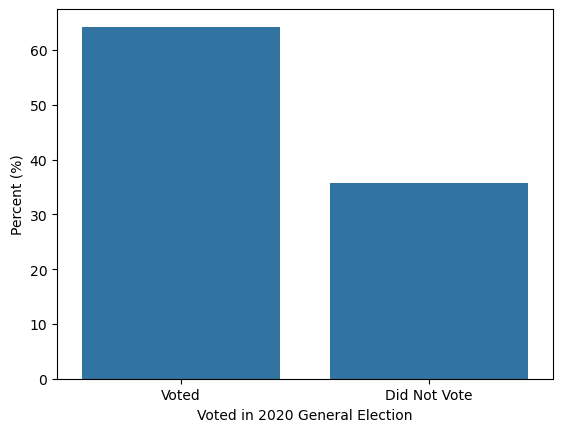

In [11]:
g=df.groupby('pvote').size().div(len(df)).mul(100).reset_index(name='percent')
g['pvote']=pd.Categorical(g['pvote'],categories=[1,0],ordered=True)
g['pvote']=g['pvote'].cat.rename_categories(['Voted','Did Not Vote'])
sns.barplot(x='pvote',y='percent',data=g)
plt.xlabel('Voted in 2020 General Election')
plt.ylabel('Percent (%)')
plt.savefig('voteper.png',dpi=300,bbox_inches='tight')
plt.show()

In [12]:
#recode faminc_new=97 as missing
df.loc[df['faminc_new']==97,'faminc_new']=np.nan
#recode urbancity=5 as missing
df.loc[df['urbancity']==5,'urbancity']=np.nan
#recode ownhome=3 as missing
df.loc[df['ownhome']==3,'ownhome']=np.nan

In [13]:
#complete cases
dcols=['age','gender','educ','race','faminc_new','marstat','region','urbancity','ownhome']
print(len(df))
print(len(df.dropna(subset=dcols)))

61000
52066


In [14]:
#drop incomplete cases
df=df.dropna(subset=dcols)

In [15]:
#focus on random 2500 respondents and balance out voting class
df_sample=(df.groupby('pvote').sample(n=1250,random_state=507))

In [16]:
df_sample['pvote'].value_counts(dropna=False)

pvote
0    1250
1    1250
Name: count, dtype: int64

In [17]:
for c in dcols:
    print(df_sample[c].value_counts())
    print('-----')

age
26    65
59    62
29    60
28    60
64    59
      ..
89     1
88     1
92     1
91     1
87     1
Name: count, Length: 74, dtype: int64
-----
gender
2    1449
1    1051
Name: count, dtype: int64
-----
educ
2    748
5    522
3    513
6    359
4    274
1     84
Name: count, dtype: int64
-----
race
1    1751
2     323
3     234
4      76
6      55
7      35
5      21
8       5
Name: count, dtype: int64
-----
faminc_new
3.0     320
4.0     266
5.0     230
9.0     226
6.0     224
1.0     196
2.0     194
8.0     183
10.0    158
7.0     156
11.0    152
12.0    100
13.0     54
14.0     23
16.0      9
15.0      9
Name: count, dtype: int64
-----
marstat
1.0    1145
5.0     723
3.0     273
6.0     175
4.0     124
2.0      60
Name: count, dtype: int64
-----
region
3    955
2    564
4    519
1    462
Name: count, dtype: int64
-----
urbancity
2.0    946
1.0    702
4.0    481
3.0    371
Name: count, dtype: int64
-----
ownhome
1.0    1496
2.0    1004
Name: count, dtype: int64
-----


## Recode Categorical Variables with Small Group Counts and Bivariate Analysis between Predictors and Voting

### Educational Attainment
1: No high school

2: High school graduate

3: Some college

4: 2-year college degree

5: 4-year college degree

6: Post-grad

In [18]:
df_sample['educ'].value_counts()

educ
2    748
5    522
3    513
6    359
4    274
1     84
Name: count, dtype: int64

In [19]:
df_sample['HaveBA']=0
df_sample.loc[(df_sample['educ']==5) | (df_sample['educ']==6),'HaveBA']=1
df_sample['HaveBA'].value_counts()

HaveBA
0    1619
1     881
Name: count, dtype: int64

In [20]:
pd.crosstab(df_sample['pvote'], df_sample['HaveBA'])

HaveBA,0,1
pvote,,
0,923,327
1,696,554


In [21]:
pd.crosstab(df_sample['pvote'], df_sample['HaveBA']).div(pd.crosstab(df_sample['pvote'], df_sample['HaveBA']).sum(axis=1),axis=0)

HaveBA,0,1
pvote,,
0,0.7384,0.2616
1,0.5568,0.4432


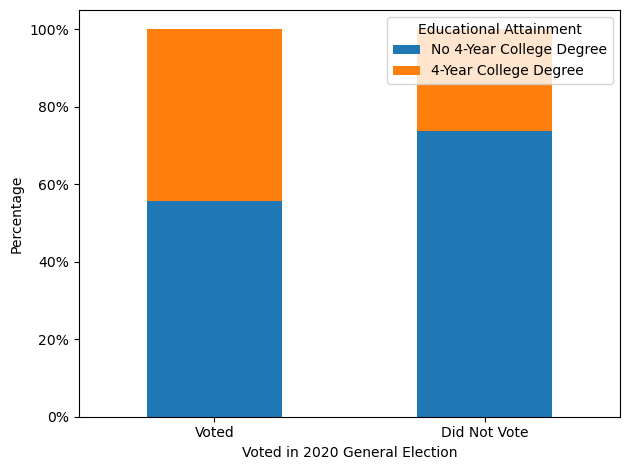

In [22]:
e=pd.crosstab(df_sample['pvote'], df_sample['HaveBA']).div(pd.crosstab(df_sample['pvote'], df_sample['HaveBA']).sum(axis=1),axis=0).reset_index()

e=e.rename(columns={0:'No 4-Year College Degree',1:'4-Year College Degree'})
e['pvote']=e['pvote'].map({1:'Voted',0:'Did Not Vote'})
e['pvote']=pd.Categorical(e['pvote'],categories=['Voted','Did Not Vote'],ordered=True)
e=e.sort_values('pvote')
e=e.set_index('pvote')

ax = e.plot(kind='bar',stacked=True)

ax.set_ylabel('Percentage')
ax.set_xlabel('Voted in 2020 General Election')
ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(title='Educational Attainment')
plt.tight_layout()
plt.savefig('voteeduc.png',dpi=300,bbox_inches='tight')
plt.show()

### Race/Ethnicity
1: White

2: Black

3: Hispanic

4: Asian

5: Native American

6: Middle Eastern

7: Two or more races

8: Other

In [23]:
df_sample['race'].value_counts()

race
1    1751
2     323
3     234
4      76
6      55
7      35
5      21
8       5
Name: count, dtype: int64

In [24]:
df_sample['hispanic'].value_counts()

hispanic
2.0    2182
1.0      83
Name: count, dtype: int64

In [25]:
#1: White Non-Hispanic
#2: Black Non-Hispanic
#3: Hispanic
#4: Other
df_sample['raceeth']=4
df_sample.loc[df_sample['race']==1,'raceeth']=1
df_sample.loc[df_sample['race']==2,'raceeth']=2
df_sample.loc[df_sample['hispanic']==1,'raceeth']=3
df_sample.loc[df_sample['race']==3,'raceeth']=3
df_sample['raceeth'].value_counts()

raceeth
1    1712
3     317
2     309
4     162
Name: count, dtype: int64

In [26]:
pd.crosstab(df_sample['pvote'], df_sample['raceeth'])

raceeth,1,2,3,4
pvote,,,,
0,776,185,200,89
1,936,124,117,73


In [27]:
pd.crosstab(df_sample['pvote'], df_sample['raceeth']).div(pd.crosstab(df_sample['pvote'], df_sample['raceeth']).sum(axis=1),axis=0)

raceeth,1,2,3,4
pvote,,,,
0,0.6208,0.1480,0.1600,0.0712
1,0.7488,0.0992,0.0936,0.0584


### Family Income
1: <$10k

2: $10-20k

3: $20-30k

4: $30-40k

5: $40-50k

6: $50-60k

7: $60-70k

8: $70-80k

9: $80-100k

10: $100-120k

11: $120-150k

12: $150-200k

13: $200-250k

14: $250-350k

15: $350-500k

16: $500k+


In [28]:
df_sample['faminc_new'].value_counts()

faminc_new
3.0     320
4.0     266
5.0     230
9.0     226
6.0     224
1.0     196
2.0     194
8.0     183
10.0    158
7.0     156
11.0    152
12.0    100
13.0     54
14.0     23
16.0      9
15.0      9
Name: count, dtype: int64

In [29]:
#create continuous approximation using midpoint rather than collapsing binning
df_sample['income']=0
df_sample.loc[df_sample['faminc_new']==1,'income']=5000
df_sample.loc[df_sample['faminc_new']==2,'income']=15000
df_sample.loc[df_sample['faminc_new']==3,'income']=25000
df_sample.loc[df_sample['faminc_new']==4,'income']=35000
df_sample.loc[df_sample['faminc_new']==5,'income']=45000
df_sample.loc[df_sample['faminc_new']==6,'income']=55000
df_sample.loc[df_sample['faminc_new']==7,'income']=65000
df_sample.loc[df_sample['faminc_new']==8,'income']=75000
df_sample.loc[df_sample['faminc_new']==9,'income']=90000
df_sample.loc[df_sample['faminc_new']==10,'income']=110000
df_sample.loc[df_sample['faminc_new']==11,'income']=135000
df_sample.loc[df_sample['faminc_new']==12,'income']=175000
df_sample.loc[df_sample['faminc_new']==13,'income']=225000
df_sample.loc[df_sample['faminc_new']==14,'income']=300000
df_sample.loc[df_sample['faminc_new']==15,'income']=425000
df_sample.loc[df_sample['faminc_new']==16,'income']=600000 #assumption for 500k+
df_sample['income'].value_counts()

income
25000     320
35000     266
45000     230
90000     226
55000     224
5000      196
15000     194
75000     183
110000    158
65000     156
135000    152
175000    100
225000     54
300000     23
600000      9
425000      9
Name: count, dtype: int64

In [30]:
df_sample.groupby('pvote',observed=True,as_index=False)['income'].median()

,pvote,income
0,0,45000.0
1,1,65000.0


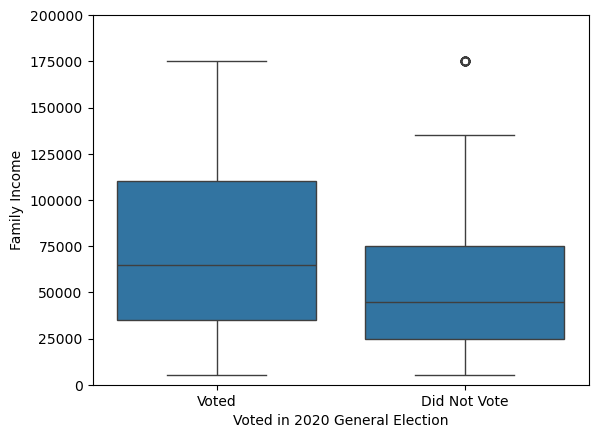

In [31]:
a=df_sample[['pvote','income']].copy()
a['pvote']=pd.Categorical(a['pvote'],categories=[1,0],ordered=True)
a['pvote']=a['pvote'].cat.rename_categories(['Voted','Did Not Vote'])
sns.boxplot(x='pvote',y='income',data=a)
plt.xlabel('Voted in 2020 General Election')
plt.ylabel('Family Income')
plt.ylim(0,200000)
plt.savefig('voteincomebox_lim.png',dpi=300,bbox_inches='tight')
plt.show()

### Marital Status
1: married

2: separated

3: divorced

4: widowed

5: never married

6: domestic/civil partnership

In [32]:
df_sample['marstat'].value_counts()

marstat
1.0    1145
5.0     723
3.0     273
6.0     175
4.0     124
2.0      60
Name: count, dtype: int64

In [33]:
df_sample['married']=0
df_sample.loc[df_sample['marstat']==1,'married']=1
df_sample['married'].value_counts()

married
0    1355
1    1145
Name: count, dtype: int64

In [34]:
pd.crosstab(df_sample['pvote'], df_sample['married'])

married,0,1
pvote,,
0,764,486
1,591,659


In [35]:
pd.crosstab(df_sample['pvote'], df_sample['married']).div(pd.crosstab(df_sample['pvote'], df_sample['married']).sum(axis=1),axis=0)

married,0,1
pvote,,
0,0.6112,0.3888
1,0.4728,0.5272


### U.S. Census Region
1: northeast

2: midwest

3: south

4: west

In [36]:
df_sample['region'].value_counts()

region
3    955
2    564
4    519
1    462
Name: count, dtype: int64

In [37]:
pd.crosstab(df_sample['pvote'], df_sample['region'])

region,1,2,3,4
pvote,,,,
0,228,252,509,261
1,234,312,446,258


In [38]:
pd.crosstab(df_sample['pvote'], df_sample['region']).div(pd.crosstab(df_sample['pvote'], df_sample['region']).sum(axis=1),axis=0)

region,1,2,3,4
pvote,,,,
0,0.1824,0.2016,0.4072,0.2088
1,0.1872,0.2496,0.3568,0.2064


### Urbanicity

1: city

2: suburb

3: town

4: rural area

In [39]:
df_sample['urbancity'].value_counts()

urbancity
2.0    946
1.0    702
4.0    481
3.0    371
Name: count, dtype: int64

In [40]:
pd.crosstab(df_sample['pvote'], df_sample['urbancity'])

urbancity,1.0,2.0,3.0,4.0
pvote,,,,
0,380,450,186,234
1,322,496,185,247


In [41]:
pd.crosstab(df_sample['pvote'], df_sample['urbancity']).div(pd.crosstab(df_sample['pvote'], df_sample['urbancity']).sum(axis=1),axis=0)

urbancity,1.0,2.0,3.0,4.0
pvote,,,,
0,0.3040,0.3600,0.1488,0.1872
1,0.2576,0.3968,0.1480,0.1976


### Home Ownership
1: own

2: rent

In [42]:
df_sample['ownhome'].value_counts()

ownhome
1.0    1496
2.0    1004
Name: count, dtype: int64

In [43]:
pd.crosstab(df_sample['pvote'], df_sample['ownhome'])

ownhome,1.0,2.0
pvote,,
0,621,629
1,875,375


In [44]:
pd.crosstab(df_sample['pvote'], df_sample['ownhome']).div(pd.crosstab(df_sample['pvote'], df_sample['ownhome']).sum(axis=1),axis=0)

ownhome,1.0,2.0
pvote,,
0,0.4968,0.5032
1,0.7000,0.3000


### Gender
1: male

2: female

In [45]:
df_sample['gender'].value_counts()

gender
2    1449
1    1051
Name: count, dtype: int64

In [46]:
pd.crosstab(df_sample['pvote'], df_sample['gender'])

gender,1,2
pvote,,
0,477,773
1,574,676


In [47]:
pd.crosstab(df_sample['pvote'], df_sample['gender']).div(pd.crosstab(df_sample['pvote'], df_sample['gender']).sum(axis=1),axis=0)

gender,1,2
pvote,,
0,0.3816,0.6184
1,0.4592,0.5408


### Age

In [48]:
df_sample.groupby('pvote',observed=True,as_index=False)['age'].mean()

,pvote,age
0,0,41.2280
1,1,52.6384


In [49]:
df_sample.groupby('pvote',observed=True,as_index=False)['age'].median()

,pvote,age
0,0,38.0
1,1,55.0


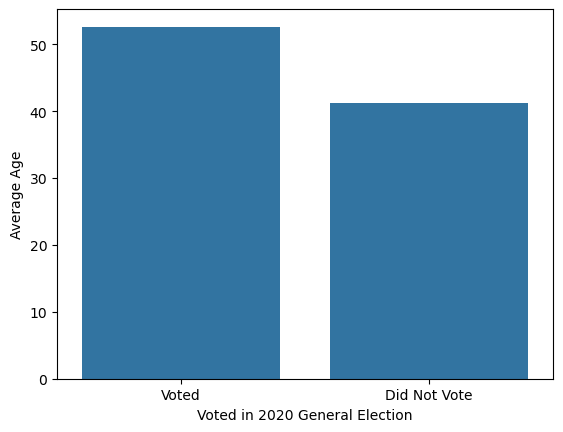

In [50]:
a=df_sample.groupby('pvote',observed=True,as_index=False)['age'].mean()
a['pvote']=pd.Categorical(a['pvote'],categories=[1,0],ordered=True)
a['pvote']=a['pvote'].cat.rename_categories(['Voted','Did Not Vote'])
sns.barplot(x='pvote',y='age',data=a)
plt.xlabel('Voted in 2020 General Election')
plt.ylabel('Average Age')
plt.savefig('voteageavg.png',dpi=300,bbox_inches='tight')
plt.show()

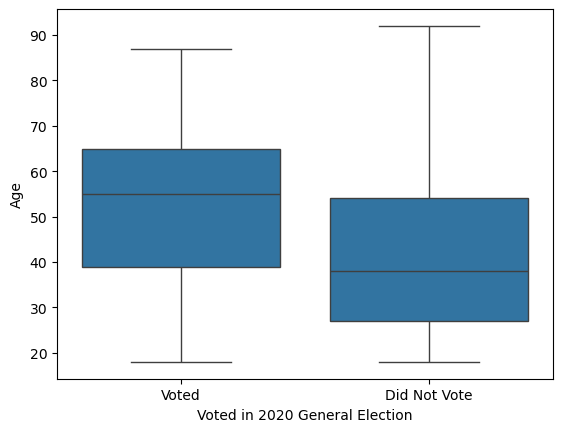

In [51]:
a=df_sample[['pvote','age']].copy()
a['pvote']=pd.Categorical(a['pvote'],categories=[1,0],ordered=True)
a['pvote']=a['pvote'].cat.rename_categories(['Voted','Did Not Vote'])
sns.boxplot(x='pvote',y='age',data=a)
plt.xlabel('Voted in 2020 General Election')
plt.ylabel('Age')
plt.savefig('voteagebox.png',dpi=300,bbox_inches='tight')
plt.show()

## Models

output: pvote

input:

&nbsp; &nbsp; continuous: age, income

&nbsp; &nbsp; categorical: gender, HaveBA, raceeth, married, region, urbancity, ownhome

In [52]:
#create dummy variables for each group in categorical variables (except reference category)
df_samplef=df_sample[['raceeth','region','urbancity','gender','HaveBA','married','ownhome','age','income','pvote']]
df_samplef=pd.get_dummies(df_samplef,columns=['raceeth','region','urbancity','gender','HaveBA','married','ownhome','pvote'],drop_first=True)
df_samplef

,age,income,raceeth_2,raceeth_3,raceeth_4,region_2,region_3,region_4,urbancity_2.0,urbancity_3.0,urbancity_4.0,gender_2,HaveBA_1,married_1,ownhome_2.0,pvote_1
54377,25,35000,True,False,False,False,True,False,False,True,False,False,False,False,True,False
113,34,90000,False,False,True,True,False,False,True,False,False,False,True,True,False,False
11200,69,45000,False,False,False,False,True,False,False,False,True,False,True,False,False,False
13725,26,35000,False,True,False,True,False,False,True,False,False,True,True,False,False,False
7982,73,25000,False,False,False,False,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38828,73,110000,False,False,False,False,True,False,False,False,True,True,True,True,False,True
48419,59,90000,False,False,False,False,False,True,True,False,False,False,False,False,False,True
36192,72,65000,False,False,False,False,True,False,False,True,False,False,True,True,False,True
29390,60,45000,False,False,False,False,False,True,True,False,False,True,False,True,False,True


In [53]:
#split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(df_samplef.iloc[:,:-1], df_samplef.iloc[:,-1], test_size=0.2, random_state=507, stratify=df_samplef.iloc[:,-1])

### Gradient Boosting

In [54]:
gb=GradientBoostingClassifier(random_state=507,n_estimators=100,learning_rate=.1,max_leaf_nodes=3)
gb.fit(X_train,y_train)
train_pred=gb.predict(X_train)
test_pred=gb.predict(X_test)
train_ac_gb=accuracy_score(y_train,train_pred)
test_ac_gb=accuracy_score(y_test,test_pred)
print(train_ac_gb)
print(test_ac_gb)

0.696
0.672


In [55]:
importances=gb.feature_importances_
for feature, importance in zip(X_train.columns, importances):
    print(f"{feature}:{importance:.3f}")

age:0.591
income:0.137
raceeth_2:0.001
raceeth_3:0.015
raceeth_4:0.009
region_2:0.008
region_3:0.003
region_4:0.007
urbancity_2.0:0.002
urbancity_3.0:0.006
urbancity_4.0:0.000
gender_2:0.035
HaveBA_1:0.141
married_1:0.002
ownhome_2.0:0.043


### Random Forest

In [56]:
rf=RandomForestClassifier(random_state=507)
rf.fit(X_train,y_train)
train_pred=rf.predict(X_train)
test_pred=rf.predict(X_test)
train_ac_rf=accuracy_score(y_train,train_pred)
test_ac_rf=accuracy_score(y_test,test_pred)
print(train_ac_rf)
print(test_ac_rf)

0.9935
0.63


In [57]:
importances=rf.feature_importances_
for feature, importance in zip(X_train.columns, importances):
    print(f"{feature}:{importance:.3f}")

age:0.375
income:0.216
raceeth_2:0.024
raceeth_3:0.025
raceeth_4:0.018
region_2:0.029
region_3:0.031
region_4:0.026
urbancity_2.0:0.034
urbancity_3.0:0.024
urbancity_4.0:0.025
gender_2:0.047
HaveBA_1:0.046
married_1:0.036
ownhome_2.0:0.043


## Logistic Regression

In [58]:
lr=LogisticRegression(max_iter=2000)
lr.fit(X_train,y_train)
train_pred=lr.predict(X_train)
test_pred=lr.predict(X_test)
train_ac_lr=accuracy_score(y_train,train_pred)
test_ac_lr=accuracy_score(y_test,test_pred)
print(train_ac_lr)
print(test_ac_lr)

0.6665
0.662


In [59]:
lr.coef_

array([[ 3.77082310e-02,  1.71450480e-06, -1.75870460e-01,
        -4.03235464e-01, -5.45871142e-01,  1.94282391e-01,
        -9.03598547e-02,  1.01330646e-01,  3.80768603e-02,
        -3.32695275e-02,  3.64998174e-02, -1.25109886e-01,
         7.79345167e-01,  1.52876538e-03, -2.99814405e-01]])

In [60]:
X_train.columns

Index(['age', 'income', 'raceeth_2', 'raceeth_3', 'raceeth_4', 'region_2',
       'region_3', 'region_4', 'urbancity_2.0', 'urbancity_3.0',
       'urbancity_4.0', 'gender_2', 'HaveBA_1', 'married_1', 'ownhome_2.0'],
      dtype='object')

### Logistic Regression with Scaling and L1 Regularization

In [61]:
#scaling because predictors have different units/scales and L1 penalty for Lasso-style regularization (feature selection)
pipeline=Pipeline([('scaler',StandardScaler()),('model',LogisticRegression(max_iter=2000,penalty='l1',solver='liblinear',C=.1))])
pipeline.fit(X_train,y_train)
train_pred=pipeline.predict(X_train)
test_pred=pipeline.predict(X_test)
train_ac_lrs=accuracy_score(y_train,train_pred)
test_ac_lrs=accuracy_score(y_test,test_pred)
print(train_ac_lrs)
print(test_ac_lrs)

0.662
0.67


In [62]:
pipeline.named_steps['model'].coef_

array([[ 0.63635945,  0.10393273, -0.03669249, -0.10524511, -0.09342019,
         0.0472037 , -0.05588494,  0.        ,  0.        ,  0.        ,
         0.        , -0.04217658,  0.35285598,  0.        , -0.14113779]])

In [63]:
pipeline.named_steps['scaler'].scale_

array([1.73987057e+01, 6.71721236e+04, 3.31284998e-01, 3.29010258e-01,
       2.49154069e-01, 4.18239166e-01, 4.86357893e-01, 4.01492217e-01,
       4.83863617e-01, 3.55594924e-01, 3.90312375e-01, 4.93639291e-01,
       4.77282935e-01, 4.97786099e-01, 4.90892045e-01])

In [64]:
X_train['age'].std()

17.403057000035176

In [65]:
X_train['income'].std()

67188.92296677122